Import the libraries

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pywt

from glob import glob
import re

Import the files

In [2]:
pattern = re.compile(r'.*\.(png|jpg)$', re.IGNORECASE)
images = [file for file in glob('*') if pattern.match(file)]
for i in range(len(images)): print(f'{i}:{images[i]}')

0:test1.jpg
1:test3.jpg
2:test2.jpg


Read the Images with grayscale

In [3]:
image = cv2.imread(images[2], cv2.IMREAD_GRAYSCALE)

Plot the Original images

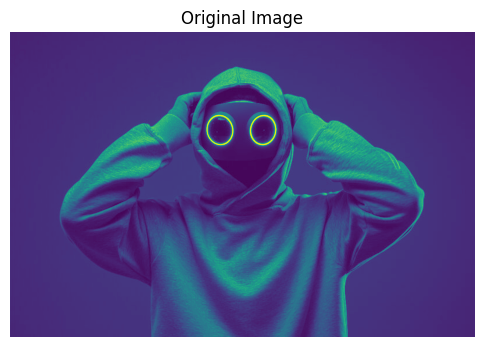

In [4]:
plt.figure(figsize=(6, 6))
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')
plt.show()

### Fourier Transform Visualization

The Fourier Transform decomposes an image into its sinusoidal frequency components:

- Represents the frequency domain of the image.
- Useful for analyzing periodic patterns and filtering.
- The magnitude spectrum illustrates the distribution of frequency intensities.

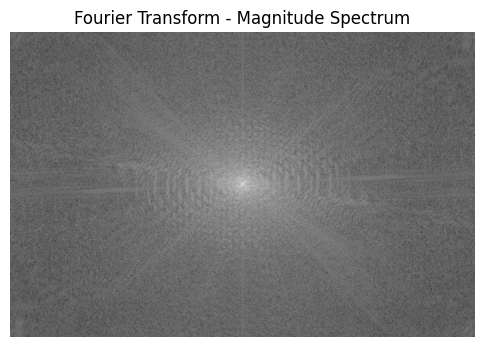

In [5]:
f_transform = np.fft.fft2(image)
f_shift = np.fft.fftshift(f_transform)
magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)

plt.figure(figsize=(6, 6))
plt.title("Fourier Transform - Magnitude Spectrum")
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')
plt.show()

### Discrete Cosine Transform (DCT) Visualization

The DCT transforms spatial image data into the frequency domain, focusing on energy compaction:

- Highlights the image's frequency components.
- Useful for compression and signal processing.
- The resulting spectrum represents the energy distribution across frequencies.

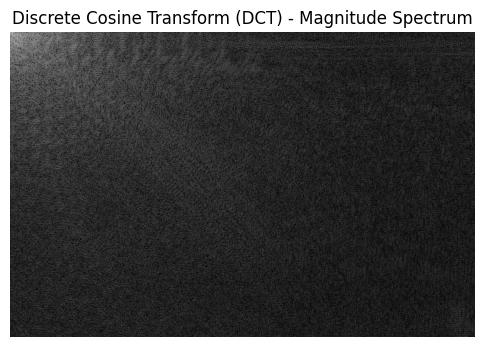

In [6]:
dct = cv2.dct(np.float32(image))
magnitude_spectrum = np.log(np.abs(dct) + 1)

plt.figure(figsize=(6, 6))
plt.title("Discrete Cosine Transform (DCT) - Magnitude Spectrum")
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')
plt.show()

### Discrete Wavelet Transform (DWT) Visualization

The DWT decomposes the image into four components:

- **Approximation (LL):** Captures the overall structure and low-frequency details.
- **Horizontal Detail (LH):** Highlights horizontal edge features.
- **Vertical Detail (HL):** Highlights vertical edge features.
- **Diagonal Detail (HH):** Captures diagonal edge features.


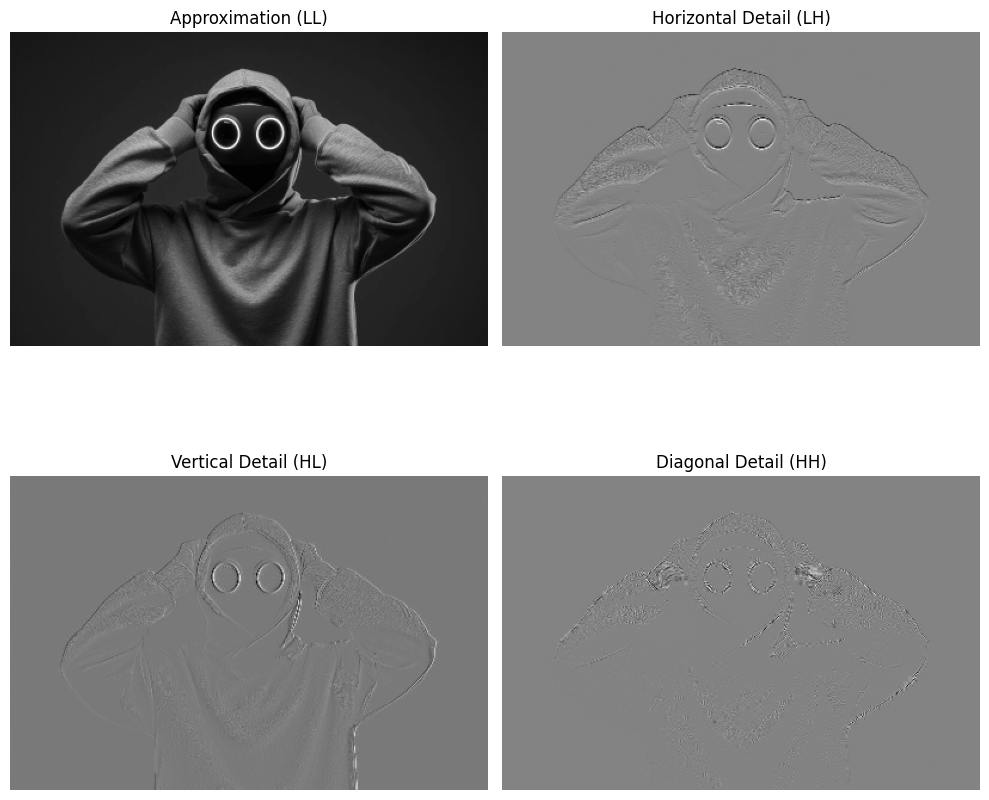

In [7]:
coeffs2 = pywt.dwt2(image, 'haar')
LL, (LH, HL, HH) = coeffs2

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.title("Approximation (LL)")
plt.imshow(LL, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Horizontal Detail (LH)")
plt.imshow(LH, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Vertical Detail (HL)")
plt.imshow(HL, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Diagonal Detail (HH)")
plt.imshow(HH, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()
